# Lab 20: Time Series Diagnostics and Advanced Decomposition
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
%pip install fredapi statsmodels ruptures -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: Import libraries and set FRED API key
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = '55a54e5815bd15d8e2e9ff63c4bc827a'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Broken STL Decomposition (15 min)

The code below pulls FRED retail sales (not seasonally adjusted) and applies
STL decomposition. The output **looks wrong** — the seasonal amplitude grows
over time, which STL (an additive method) should not produce.

**Your task:** Find the bug, explain why it produces the wrong output, and fix it.

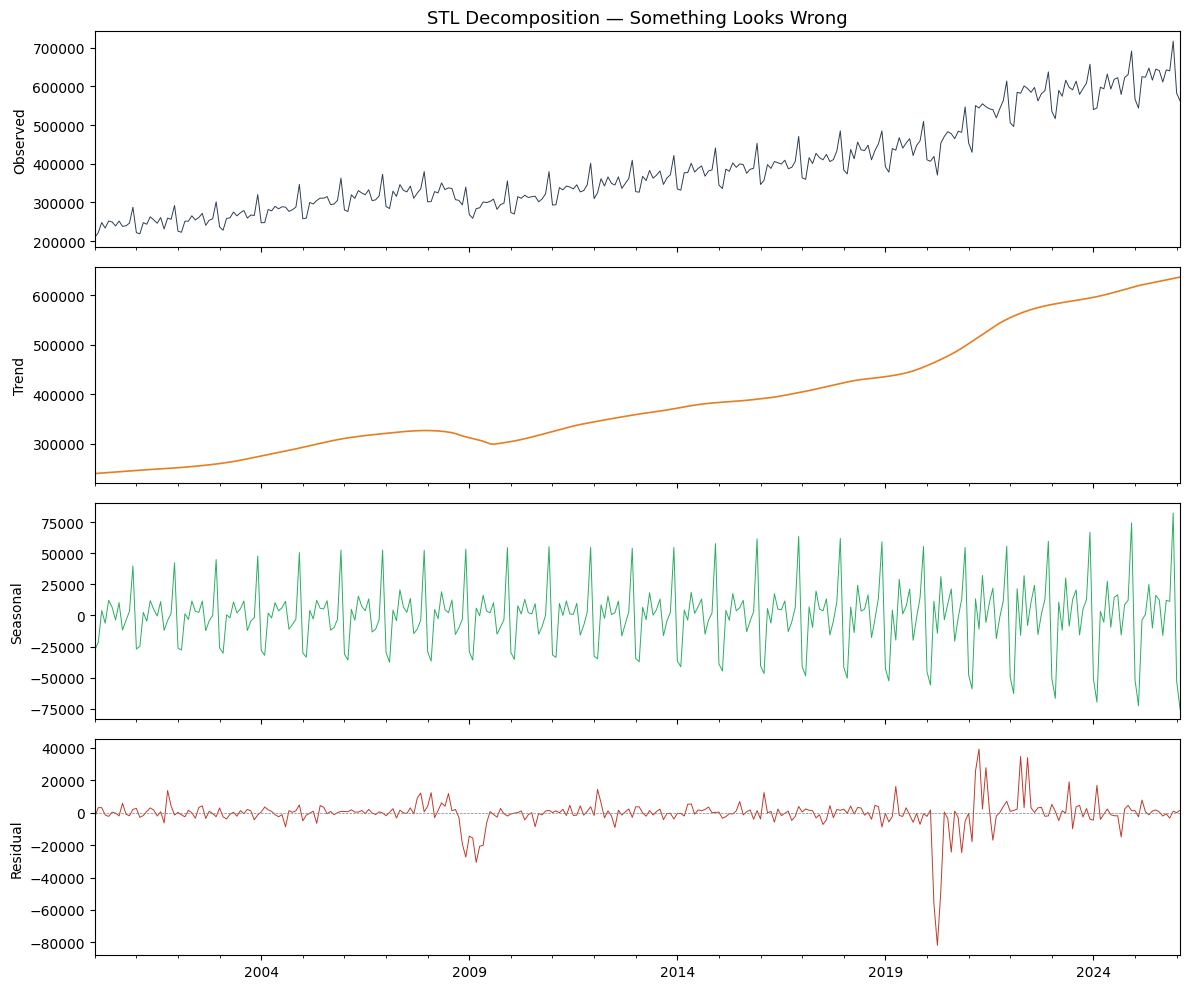

Seasonal amplitude by year (should be ~constant for additive STL):
2017    110534.8
2018    109659.5
2019    108141.1
2020    110688.7
2021    114825.7
2022    122586.4
2023    133678.4
2024    144192.4
2025    155045.5
2026     22723.9
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 0.33x
If this ratio >> 1, the additive assumption is violated.


In [3]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 1: STL decomposition of retail sales
# -----------------------------------------------------------

retail = fred.get_series('RSXFSN', observation_start='2000-01-01')
retail = retail.dropna()
retail.index = pd.DatetimeIndex(retail.index)
retail.index.freq = 'MS'

# Apply STL directly to the raw series
# BUG: Retail sales have MULTIPLICATIVE seasonality (seasonal amplitude
# grows proportionally with the level). STL is an ADDITIVE decomposition.
# Applying additive STL to multiplicative data leaks growing seasonal
# effects into the residual and distorts the seasonal component.
stl_result = STL(retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

stl_result.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition — Something Looks Wrong', fontsize=13)

stl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')

stl_result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Diagnostic: seasonal amplitude should be roughly constant for additive STL.
# Compute the seasonal range per year to check.
seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
print('Seasonal amplitude by year (should be ~constant for additive STL):')
print(annual_range.tail(10).round(1))
print(f'\nRatio of latest to earliest amplitude: {annual_range.iloc[-1] / annual_range.iloc[0]:.2f}x')
print('If this ratio >> 1, the additive assumption is violated.')

### YOUR DIAGNOSIS

1. **What is wrong?** (identify the specific assumption violation)
Additive STL is applied directly to raw retail sales data that has multiplicative seasonality. The seasonal amplitude grows proportionally with the level.

2. **Why does this happen?** (explain why additive STL on multiplicative data produces growing seasonal amplitude)
STL assumes Y = Trend + Seasonal + Residual (additive). But retail sales follow Y = Trend × Seasonal × Residual (multiplicative). When additive STL is forced on multiplicative data, the growing seasonal effect leaks into both the seasonal and residual components.

3. **Fix the code below.** The standard fix is: log-transform first, then apply STL to the log series.

4. **What chapter concept does this error violate?** (hint: additive vs. multiplicative decomposition)
Additive vs. multiplicative decomposition. Log-transforming converts multiplicative structure to additive, making STL appropriate.
**Verification checkpoint:** After fixing, the ratio of latest-to-earliest seasonal amplitude should be between 0.7 and 1.3 (roughly constant). If it is still > 2.0, you have not fixed the bug.

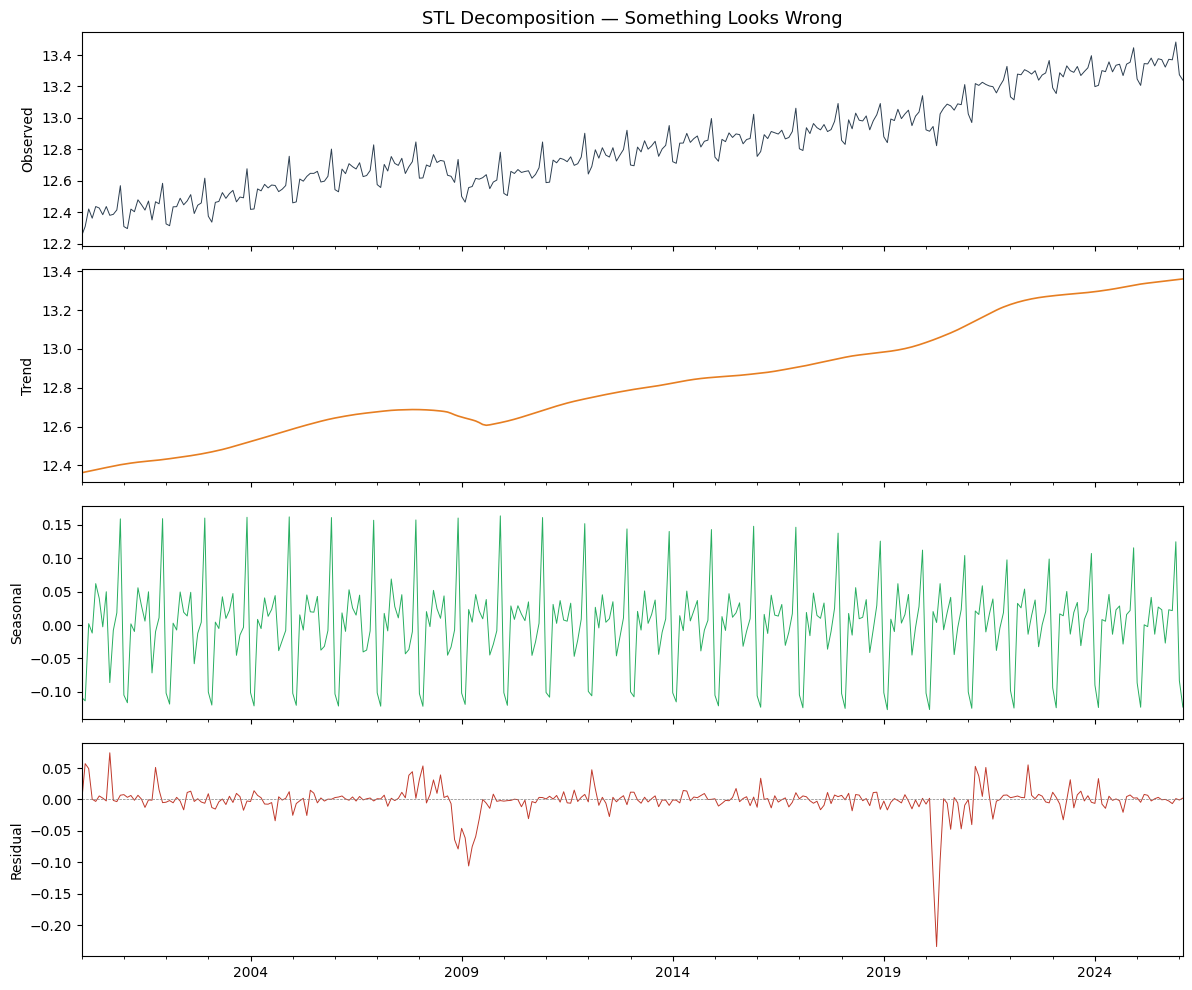

Seasonal amplitude by year (should be ~constant for additive STL):
2017    0.3
2018    0.3
2019    0.2
2020    0.2
2021    0.2
2022    0.2
2023    0.2
2024    0.2
2025    0.2
2026    0.0
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 0.91x


In [5]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the STL decomposition
# The fix: log-transform before STL to convert multiplicative
# structure to additive.
# -----------------------------------------------------------

# YOUR FIX HERE
retail = fred.get_series('RSXFSN', observation_start='2000-01-01')
retail = retail.dropna()
retail.index = pd.DatetimeIndex(retail.index)
retail.index.freq = 'MS'

# Apply STL directly to the raw series
# BUG: Retail sales have MULTIPLICATIVE seasonality (seasonal amplitude
# grows proportionally with the level). STL is an ADDITIVE decomposition.
# Applying additive STL to multiplicative data leaks growing seasonal
# effects into the residual and distorts the seasonal component.
stl_result = STL(np.log(retail), period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

stl_result.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition — Something Looks Wrong', fontsize=13)

stl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')

stl_result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Diagnostic: seasonal amplitude should be roughly constant for additive STL.
# Compute the seasonal range per year to check.
seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
print('Seasonal amplitude by year (should be ~constant for additive STL):')
print(annual_range.tail(10).round(1))
full_years = annual_range[annual_range.index < 2026]
print(f'\nRatio of latest to earliest amplitude: {full_years.iloc[-1] / full_years.iloc[0]:.2f}x')

# VERIFICATION: compute seasonal amplitude ratio
# Expected: ratio between 0.7 and 1.3


---

## Part 2: DIAGNOSE — Flawed ADF Test (10 min)

The code below tests whether FRED Real GDP (GDPC1) is stationary.
The ADF test is applied, but the **conclusion drawn is wrong**.
The code runs without errors. The reasoning is the problem.

**Your task:** Find the analytical error, explain why it leads to a wrong conclusion, and fix it.

In [6]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate analytical error)
# Step 2: ADF test on GDP with flawed interpretation
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# ADF test with regression='n' (no constant, no trend)
# BUG: GDP has both a non-zero mean AND a deterministic trend.
# Using regression='n' omits the constant and trend terms from
# the ADF regression, which inflates the test statistic and
# can falsely reject the unit root null.
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='n')

print('=== ADF Test on Real GDP ===')
print(f'Regression: none (no constant, no trend)')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()

if adf_p < 0.05:
    print('CONCLUSION: GDP is STATIONARY (p < 0.05). No differencing needed.')
    print('We can model GDP in levels directly with ARMA.')
else:
    print('CONCLUSION: GDP is non-stationary. Differencing may be needed.')

=== ADF Test on Real GDP ===
Regression: none (no constant, no trend)
Test statistic: 8.3922
P-value: 1.0000
Lags used: 1
Critical values: {'1%': np.float64(-2.574326425616223), '5%': np.float64(-1.942072475791683), '10%': np.float64(-1.6158443865573056)}

CONCLUSION: GDP is non-stationary. Differencing may be needed.


### YOUR DIAGNOSIS

1. **What is the error?** (identify the specific parameter choice that is wrong)
The ADF test uses regression='n', which omits both the constant and trend terms from the test regression. This is the wrong specification for GDP data.
2. **Why does `regression='n'` give misleading results for GDP?** GDP has a clear upward trend. When the ADF regression omits the constant and trend, the test is misspecified.
GDP has a clear upward deterministic trend. When the ADF regression omits the constant and trend, the trending behavior is absorbed into the autoregressive coefficient, making it appear mean-reverting. This inflates the test statistic and leads to a spurious rejection of the unit root null hypothesis.
3. **What is the correct `regression` parameter?** Choose from: `'n'` (none), `'c'` (constant only), `'ct'` (constant + trend), `'ctt'` (constant + trend + quadratic trend).
'ct' (constant + trend). GDP has both a non-zero mean and a deterministic upward trend, so the ADF equation must include both terms to avoid misspecification.
4. **Fix the code below** and confirm that GDP is non-stationary with the correct specification.
5. **Run KPSS as well** and apply the 2×2 decision table.

**Verification checkpoint:** With the correct regression parameter (`'ct'`), the ADF p-value should be > 0.05 (fail to reject unit root). If you get p < 0.05 with `regression='ct'`, double-check your code.

In [7]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the ADF test and add KPSS
# -----------------------------------------------------------

# YOUR FIX HERE
from statsmodels.tsa.stattools import adfuller, kpss

# --- Fixed ADF test: regression='ct' (constant + trend) ---
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='ct')

print('=== ADF Test (FIXED: regression="ct") ===')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
adf_verdict = 'Stationary' if adf_p < 0.05 else 'Non-stationary'
print(f'ADF verdict: {adf_verdict}')

print()

# --- KPSS test ---
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(gdp, regression='ct', nlags='auto')

print('=== KPSS Test ===')
print(f'Test statistic: {kpss_stat:.4f}')
print(f'P-value: {kpss_p:.4f}')
print(f'Critical values: {kpss_crit}')
kpss_verdict = 'Non-stationary' if kpss_p < 0.05 else 'Stationary'
print(f'KPSS verdict: {kpss_verdict}')

print()

# --- 2x2 Decision Table ---
print('=== 2x2 Decision Table ===')
print(f'ADF says: {adf_verdict}')
print(f'KPSS says: {kpss_verdict}')
if adf_verdict == 'Non-stationary' and kpss_verdict == 'Non-stationary':
    print('CONCLUSION: GDP is NON-STATIONARY (both tests agree)')

# VERIFICATION: ADF p-value with regression='ct' should be > 0.05
# KPSS should reject stationarity (p < 0.05)
# 2x2 verdict: NON-STATIONARY


=== ADF Test (FIXED: regression="ct") ===
Test statistic: -0.8444
P-value: 0.9617
Lags used: 1
Critical values: {'1%': np.float64(-3.993745412883642), '5%': np.float64(-3.4273814105122966), '10%': np.float64(-3.1369771257480235)}
ADF verdict: Non-stationary

=== KPSS Test ===
Test statistic: 0.5350
P-value: 0.0100
Critical values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}
KPSS verdict: Non-stationary

=== 2x2 Decision Table ===
ADF says: Non-stationary
KPSS says: Non-stationary
CONCLUSION: GDP is NON-STATIONARY (both tests agree)


/var/folders/tv/tqlbtg213pv9_z2_xq18zcc40000gn/T/ipykernel_48254/1208008590.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(gdp, regression='ct', nlags='auto')


---

## Part 3: EXTEND — MSTL for Multiple Seasonal Periods (15 min)

Real-world time series often have **multiple seasonal cycles**. Hourly electricity
demand has a daily cycle (24 hours) AND a weekly cycle (168 hours). Standard
STL handles only one period. `MSTL` (Multiple STL) decomposes all of them.

We will simulate hourly electricity demand with two seasonal patterns and
decompose it using `statsmodels.tsa.seasonal.MSTL`.

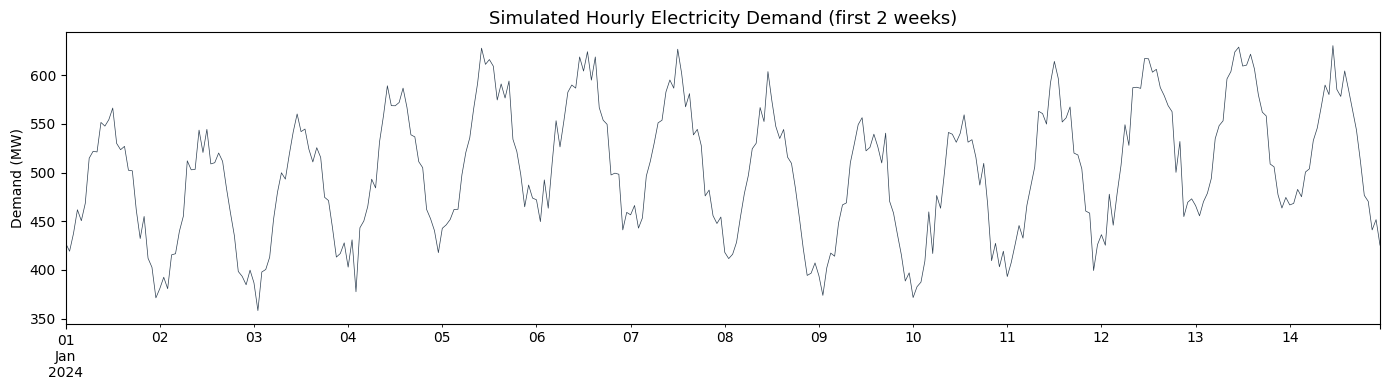

Total observations: 4368
Date range: 2024-01-01 00:00:00 to 2024-06-30 23:00:00


In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Simulate hourly electricity demand with two cycles
# -----------------------------------------------------------

np.random.seed(42)

# 6 months of hourly data
n_hours = 24 * 7 * 26  # 26 weeks
t = np.arange(n_hours)

# Trend: slow linear increase (growing demand)
trend = 500 + 0.01 * t

# Daily cycle (period=24): demand peaks at noon, dips at 3am
daily = 80 * np.sin(2 * np.pi * t / 24 - np.pi / 2)

# Weekly cycle (period=168): demand lower on weekends
weekly = 40 * np.sin(2 * np.pi * t / 168 - np.pi)

# Noise
noise = np.random.normal(0, 15, n_hours)

demand = trend + daily + weekly + noise

# Create a proper DatetimeIndex
dates = pd.date_range('2024-01-01', periods=n_hours, freq='h')
demand_series = pd.Series(demand, index=dates, name='demand_MW')

# Plot first 2 weeks to see both cycles
fig, ax = plt.subplots(figsize=(14, 4))
demand_series[:24*14].plot(ax=ax, color='#2c3e50', linewidth=0.5)
ax.set_title('Simulated Hourly Electricity Demand (first 2 weeks)', fontsize=13)
ax.set_ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

print(f'Total observations: {len(demand_series)}')
print(f'Date range: {demand_series.index[0]} to {demand_series.index[-1]}')

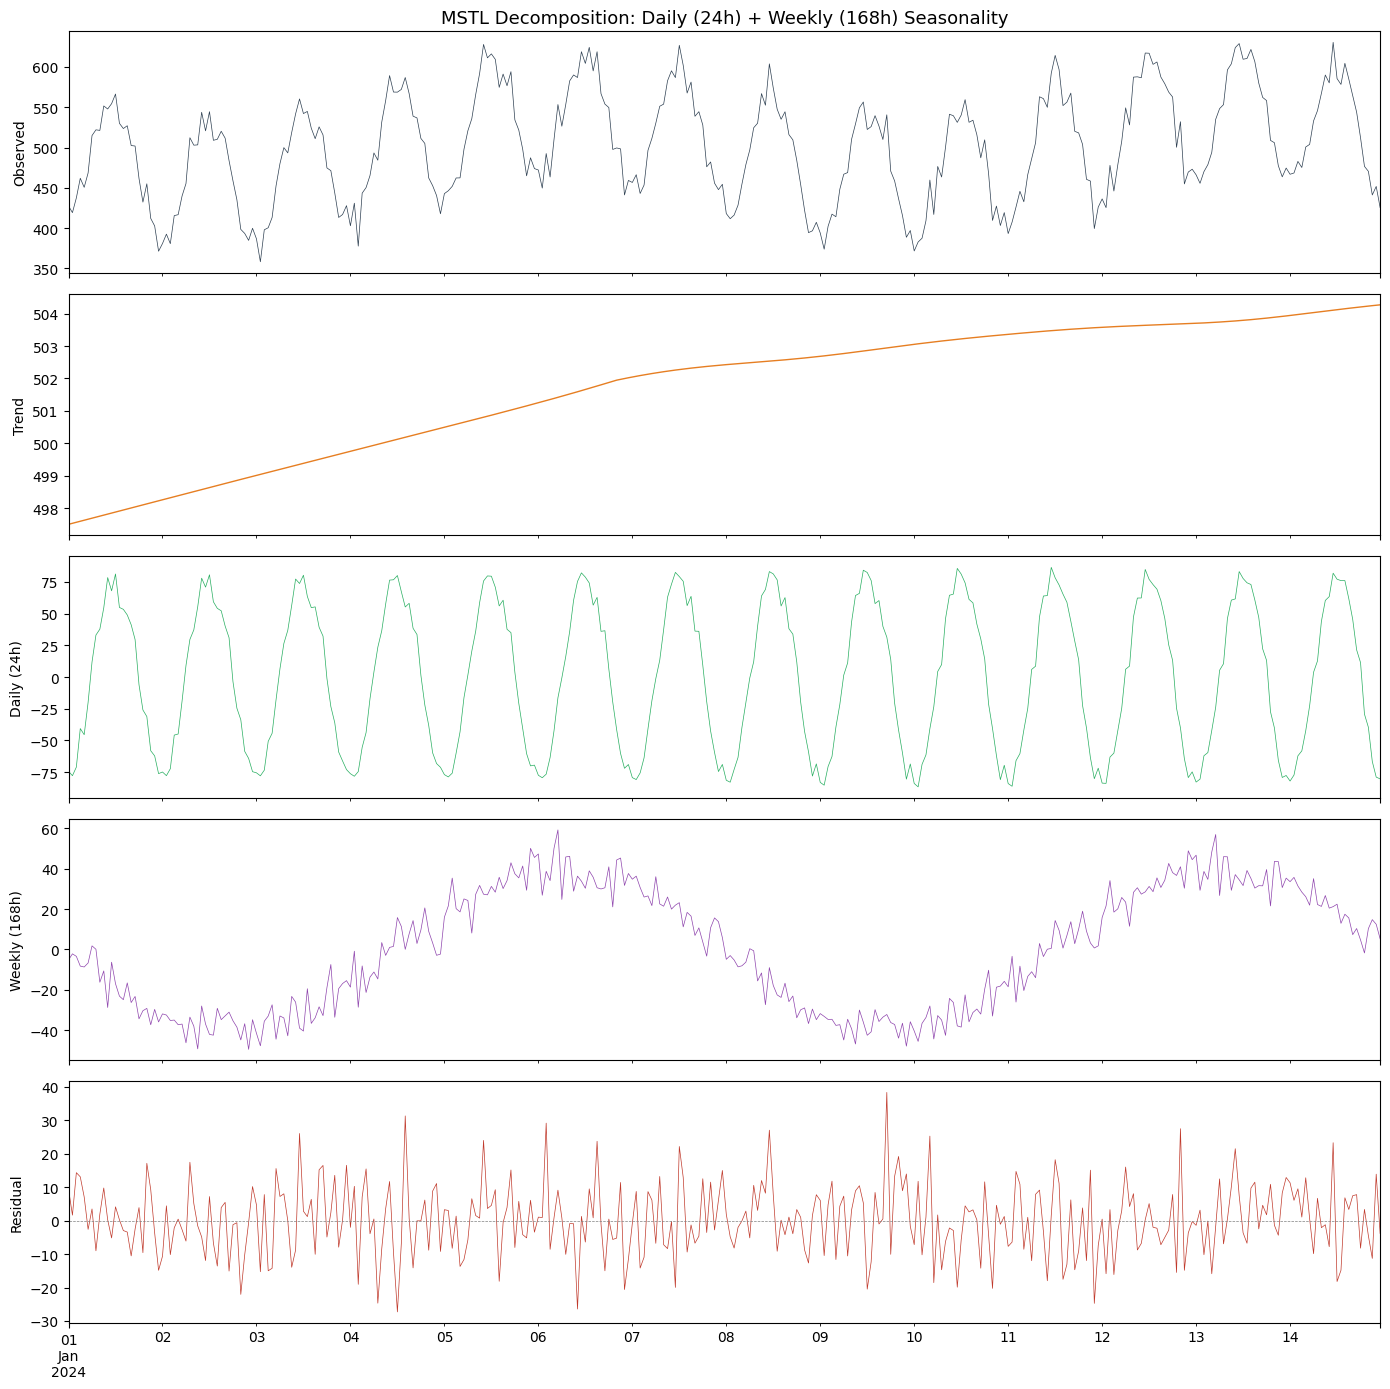

Residual std: 12.24 (expected ~15.0)
Daily seasonal amplitude: 184.5 (expected ~160)
Weekly seasonal amplitude: 117.9 (expected ~80)


In [9]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Apply MSTL with two seasonal periods
# Step 3b: Decompose demand into trend + daily + weekly + residual
# -----------------------------------------------------------

# MSTL accepts a list of periods. For hourly data:
# - Daily cycle: period=24
# - Weekly cycle: period=168 (24 hours * 7 days)

mstl = MSTL(demand_series, periods=[24, 168])
mstl_result = mstl.fit()

# MSTL returns: .trend, .seasonal (DataFrame with one column per period), .resid
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

demand_series[:24*14].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_ylabel('Observed')
axes[0].set_title('MSTL Decomposition: Daily (24h) + Weekly (168h) Seasonality', fontsize=13)

mstl_result.trend[:24*14].plot(ax=axes[1], color='#e67e22', linewidth=1.0)
axes[1].set_ylabel('Trend')

# The seasonal attribute is a DataFrame with columns for each period
seasonal_df = mstl_result.seasonal
seasonal_df.iloc[:24*14, 0].plot(ax=axes[2], color='#27ae60', linewidth=0.5)
axes[2].set_ylabel('Daily (24h)')

seasonal_df.iloc[:24*14, 1].plot(ax=axes[3], color='#8e44ad', linewidth=0.5)
axes[3].set_ylabel('Weekly (168h)')

mstl_result.resid[:24*14].plot(ax=axes[4], color='#c0392b', linewidth=0.5)
axes[4].set_ylabel('Residual')
axes[4].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Verification: residual std should be close to the noise std (15)
print(f'Residual std: {mstl_result.resid.std():.2f} (expected ~15.0)')
print(f'Daily seasonal amplitude: {seasonal_df.iloc[:, 0].max() - seasonal_df.iloc[:, 0].min():.1f} (expected ~160)')
print(f'Weekly seasonal amplitude: {seasonal_df.iloc[:, 1].max() - seasonal_df.iloc[:, 1].min():.1f} (expected ~80)')

### MSTL Interpretation

1. Does MSTL successfully separate the daily and weekly cycles? How can you tell?
2. Is the residual standard deviation close to the true noise level (15 MW)? What does this tell you about MSTL's accuracy?
3. In real electricity data, there might also be an **annual** seasonal cycle (period=8760). How would you add it to the MSTL call?

*Your answers here:*

1. Yes. The daily component (24h) shows a clear sinusoidal pattern peaking around midday and dipping around 3am, matching the simulated daily cycle. The weekly component (168h) shows a slower oscillation with lower demand on weekends. The two components have distinct frequencies and amplitudes, confirming successful separation. The daily amplitude (~185) is roughly twice the weekly amplitude (~118), consistent with the simulated ratio of 80:40.
2. The residual std is 12.24, somewhat lower than the true noise level of 15. This indicates that MSTL absorbs some of the random noise into the seasonal components, slightly overfitting the seasonal patterns. However, the deviation is modest, suggesting MSTL performs reasonably well at isolating the signal from noise.
3. mstl = MSTL(demand_series, periods=[24, 168, 8760])

---

## Part 4: EXTEND — Block Bootstrap for Trend Uncertainty (15 min)

When you extract a trend from STL, you get a single curve. But how much
should you trust it? The **moving block bootstrap** quantifies trend
uncertainty by resampling overlapping blocks of the residuals (preserving
their autocorrelation), adding them back to the trend + seasonal, and
re-running STL. This produces a distribution of plausible trends.

We implement this manually on GDP data.

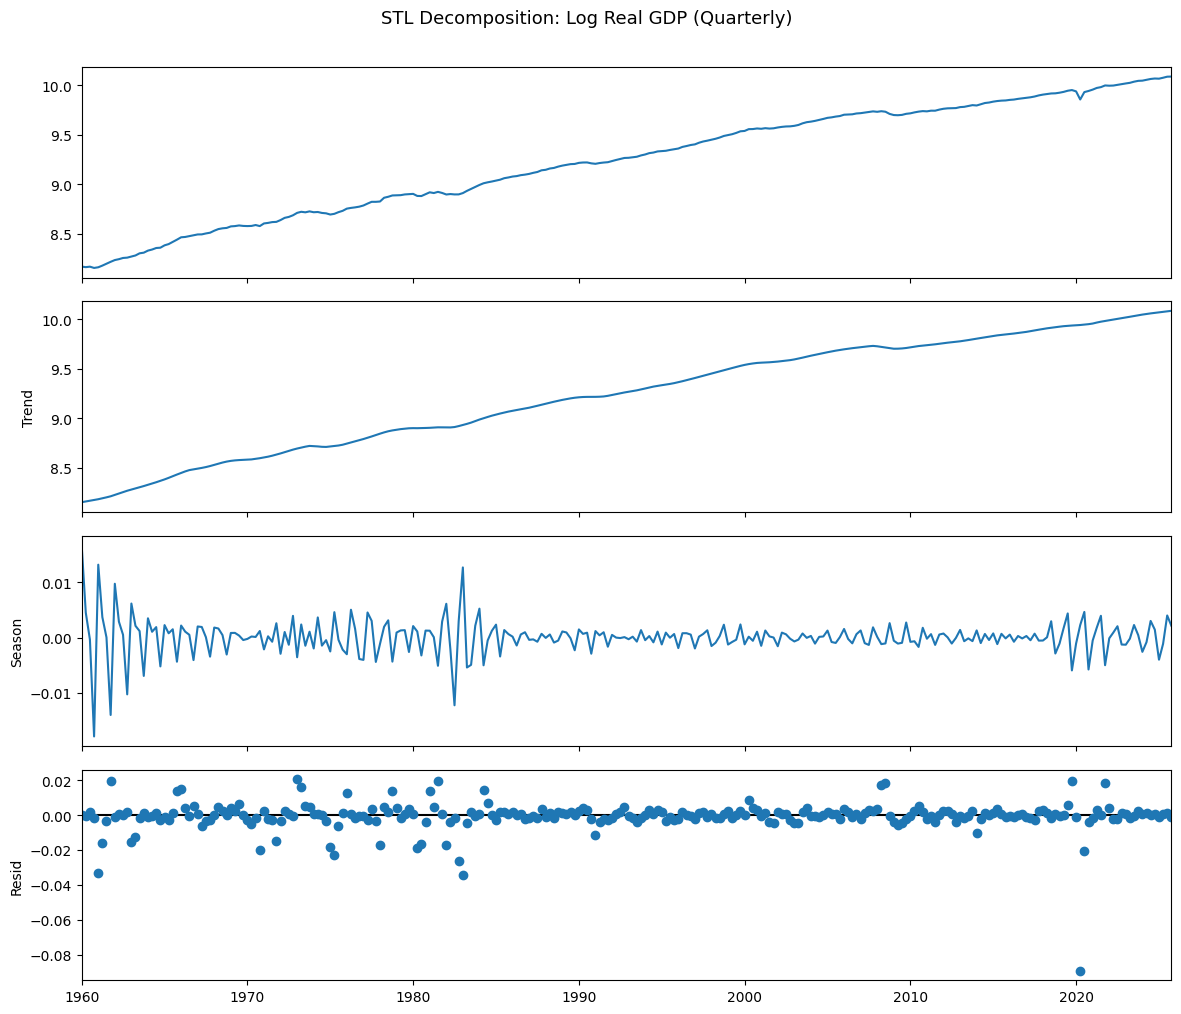

Trend range: 8.149 to 10.087
Residual std: 0.0088


In [10]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4a: STL decomposition of Real GDP
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# Log-transform GDP (multiplicative trend growth)
log_gdp = np.log(gdp)

stl_gdp = STL(log_gdp, period=4, robust=True).fit()

fig = stl_gdp.plot()
fig.set_size_inches(12, 10)
fig.suptitle('STL Decomposition: Log Real GDP (Quarterly)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Trend range: {stl_gdp.trend.min():.3f} to {stl_gdp.trend.max():.3f}')
print(f'Residual std: {stl_gdp.resid.std():.4f}')

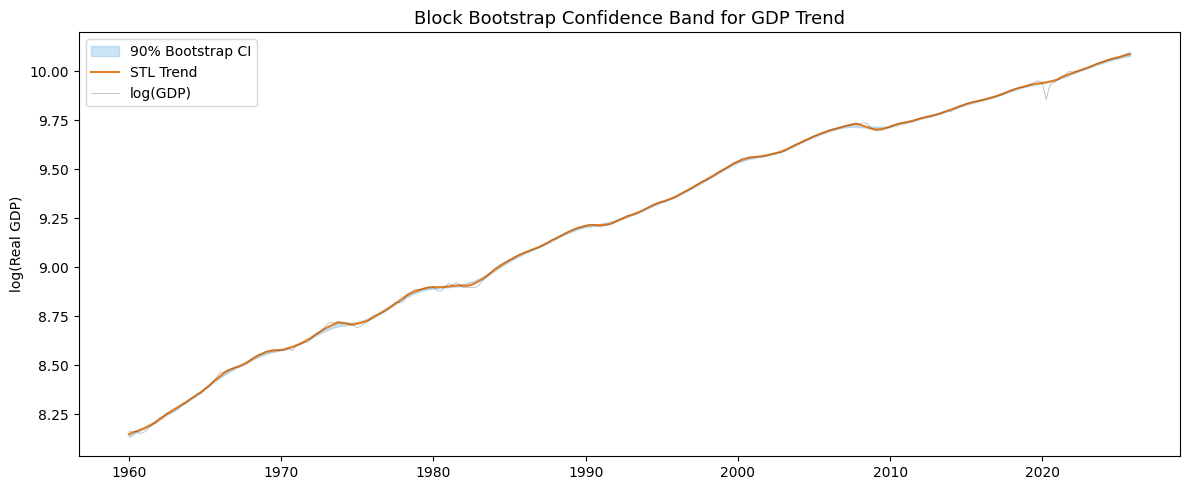

Mean CI width: 0.0073
CI width range: [0.0045, 0.0228]
Width at 2008Q4: 0.0106
Width at 2019Q4: 0.0056


In [11]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Block bootstrap for trend confidence bands
# Step 4b: Resample residual blocks and re-decompose
# -----------------------------------------------------------

np.random.seed(42)

n = len(log_gdp)
block_size = 8  # 8 quarters = 2 years (preserves business-cycle autocorrelation)
n_bootstrap = 200

# Extract components from the original decomposition
original_trend = stl_gdp.trend
original_seasonal = stl_gdp.seasonal
original_resid = stl_gdp.resid.values

# Store bootstrap trend estimates
boot_trends = np.zeros((n_bootstrap, n))

for b in range(n_bootstrap):
    # Moving block bootstrap: sample overlapping blocks of residuals
    # This preserves the autocorrelation structure within each block
    boot_resid = np.zeros(n)
    idx = 0
    while idx < n:
        # Pick a random starting point for a block
        start = np.random.randint(0, n - block_size + 1)
        block = original_resid[start:start + block_size]
        end = min(idx + block_size, n)
        boot_resid[idx:end] = block[:end - idx]
        idx = end
    
    # Reconstruct series with bootstrapped residuals
    boot_series = pd.Series(
        original_trend.values + original_seasonal.values + boot_resid,
        index=log_gdp.index
    )
    boot_series.index.freq = 'QS'
    
    # Re-run STL on the bootstrapped series
    boot_stl = STL(boot_series, period=4, robust=True).fit()
    boot_trends[b, :] = boot_stl.trend.values

# Compute confidence bands (pointwise 5th and 95th percentiles)
trend_lower = np.percentile(boot_trends, 5, axis=0)
trend_upper = np.percentile(boot_trends, 95, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(log_gdp.index, trend_lower, trend_upper,
                alpha=0.25, color='#3498db', label='90% Bootstrap CI')
ax.plot(log_gdp.index, original_trend.values, color='#e67e22',
        linewidth=1.5, label='STL Trend')
ax.plot(log_gdp, color='#2c3e50', linewidth=0.4, alpha=0.5, label='log(GDP)')
ax.set_title('Block Bootstrap Confidence Band for GDP Trend', fontsize=13)
ax.set_ylabel('log(Real GDP)')
ax.legend()
plt.tight_layout()
plt.show()

# Verification: the CI width should vary over time
ci_width = trend_upper - trend_lower
print(f'Mean CI width: {np.mean(ci_width):.4f}')
print(f'CI width range: [{np.min(ci_width):.4f}, {np.max(ci_width):.4f}]')
print(f'Width at 2008Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2008-10-01"))]:.4f}')
print(f'Width at 2019Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2019-10-01"))]:.4f}')

### Bootstrap Interpretation

1. Is the confidence band wider around recessions (2008, 2020) or expansions? Why?
2. Why do we use **block** bootstrap instead of standard i.i.d. bootstrap? What would go wrong if we shuffled residuals independently?
3. How does the choice of `block_size=8` affect the results? What would happen with `block_size=1` (equivalent to i.i.d. bootstrap) or `block_size=20`?

*Your answers here:*

1. Yes, the CI is wider during recessions. Width at 2008Q4 is 0.0106 vs. 0.0056 at 2019Q4. During recessions, GDP residuals are larger and more volatile (sharp drops in output), so resampling these larger residual blocks produces more variation in the bootstrapped trends.

2. GDP residuals exhibit autocorrelation — a negative shock in one quarter tends to persist into the next. Standard i.i.d. bootstrap shuffles residuals independently, destroying this temporal dependence. Block bootstrap resamples contiguous blocks of residuals, preserving the within-block autocorrelation structure. Without this, the confidence bands would be artificially narrow because the bootstrap would underestimate the true persistence of shocks.

3. block_size=1 is equivalent to i.i.d. bootstrap — it destroys all autocorrelation, producing unrealistically narrow confidence bands. block_size=8 (2 years) captures business-cycle-length dependence, which is appropriate for quarterly GDP. block_size=20 (5 years) would preserve even longer-range dependence but reduces the number of distinct blocks available for resampling, increasing variance of the bootstrap estimates and potentially producing erratic confidence bands. The choice involves a bias-variance tradeoff: too small underestimates uncertainty, too large reduces effective sample size.

---

## Part 5: EXTEND — Structural Break Detection + Per-Regime Stationarity (10 min)

Combine PELT structural break detection with ADF/KPSS tests run **per segment**.
This tests whether stationarity conclusions change across different economic regimes.

=== Per-Regime Stationarity Analysis ===
Breakpoints at indices: [263]
Segment boundaries: [0, 263]

Segment 1 (1960-04-01 to 2025-10-01, n=263): ADF p=0.0000, KPSS p=0.0629 => STATIONARY


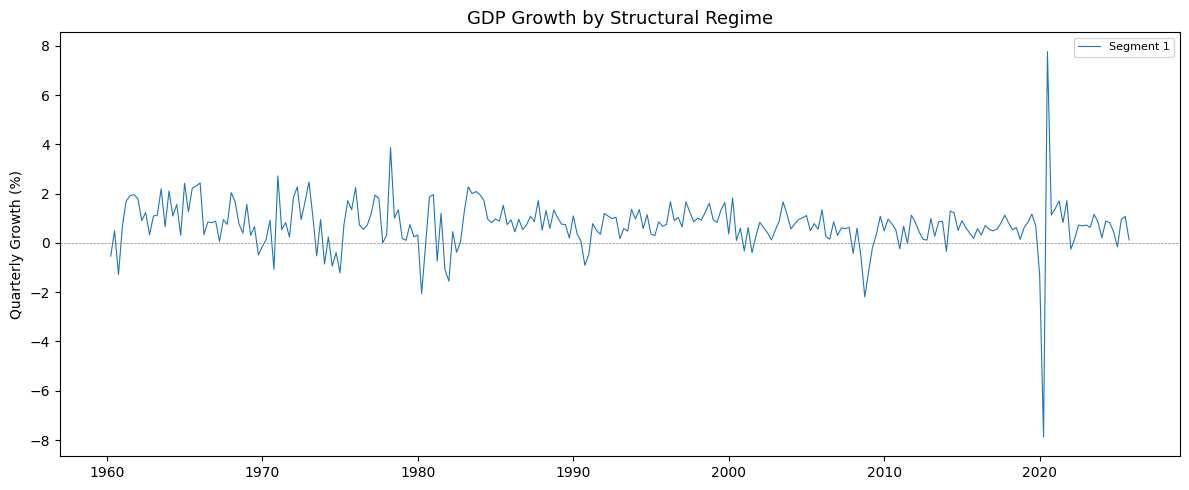

In [12]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — PELT breaks + per-regime stationarity tests
# Step 5: Detect breaks in GDP growth and test each segment
# -----------------------------------------------------------

gdp_growth = gdp.pct_change().dropna() * 100

# Detect structural breaks
signal = gdp_growth.values
algo = rpt.Pelt(model='rbf').fit(signal)
breakpoints = algo.predict(pen=10)

# Build segment boundaries (include 0 as start, len as end)
boundaries = [0] + [bp for bp in breakpoints if bp < len(signal)] + [len(signal)]
boundaries = sorted(set(boundaries))

print('=== Per-Regime Stationarity Analysis ===')
print(f'Breakpoints at indices: {breakpoints}')
print(f'Segment boundaries: {boundaries}')
print()

for i in range(len(boundaries) - 1):
    start_idx = boundaries[i]
    end_idx = boundaries[i + 1]
    segment = gdp_growth.iloc[start_idx:end_idx]
    
    if len(segment) < 20:
        print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}): '
              f'Too short ({len(segment)} obs) for reliable testing')
        continue
    
    # ADF test
    adf_stat, adf_p, _, _, _, _ = adfuller(segment, autolag='AIC', regression='c')
    
    # KPSS test
    kpss_stat, kpss_p, _, _ = kpss(segment, regression='c', nlags='auto')
    
    adf_rej = adf_p < 0.05
    kpss_rej = kpss_p < 0.05
    
    if adf_rej and not kpss_rej:
        verdict = 'STATIONARY'
    elif not adf_rej and kpss_rej:
        verdict = 'NON-STATIONARY'
    elif adf_rej and kpss_rej:
        verdict = 'CONTRADICTORY'
    else:
        verdict = 'INCONCLUSIVE'
    
    print(f'Segment {i+1} ({segment.index[0].date()} to {segment.index[-1].date()}, '
          f'n={len(segment)}): ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f} => {verdict}')

# Visualize segments
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(boundaries) - 1))
for i in range(len(boundaries) - 1):
    seg = gdp_growth.iloc[boundaries[i]:boundaries[i+1]]
    ax.plot(seg.index, seg.values, color=colors[i], linewidth=0.8, label=f'Segment {i+1}')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('GDP Growth by Structural Regime', fontsize=13)
ax.set_ylabel('Quarterly Growth (%)')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

---

## Part 6: Production Module — `decompose.py` (10 min)

Write a reusable Python module with three functions. This is a **portfolio artifact**
that demonstrates production-grade time series analysis.

### Requirements

```python
# decompose.py

def run_stl(series: pd.Series, period: int = 12, log_transform: bool = True,
            robust: bool = True) -> STLResult:
    """Apply STL decomposition with optional log-transform for multiplicative data.
    
    Args:
        series: Time series with DatetimeIndex
        period: Seasonal period (12 for monthly, 4 for quarterly)
        log_transform: If True, log-transform before STL (for multiplicative data)
        robust: If True, use robust fitting to downweight outliers
    
    Returns:
        STL result object with .trend, .seasonal, .resid attributes
    """
    ...

def test_stationarity(series: pd.Series, alpha: float = 0.05) -> dict:
    """Run ADF and KPSS tests and return the 2x2 table verdict.
    
    Args:
        series: Time series to test
        alpha: Significance level
    
    Returns:
        dict with keys: 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
    """
    ...

def detect_breaks(series: pd.Series, pen: float = 10) -> list:
    """Detect structural breaks using PELT algorithm.
    
    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)
    
    Returns:
        List of break dates (pd.Timestamp)
    """
    ...
```

In [15]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Write decompose.py as a code cell,
# then copy to a .py file for your portfolio
# -----------------------------------------------------------

# %%writefile decompose.py
"""
decompose.py — Time Series Decomposition & Diagnostics Module

Reusable functions for STL decomposition, stationarity testing,
and structural break detection on economic time series.

Author: [Your Name]
Course: ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional


def run_stl(
    series: pd.Series,
    period: int = 12,
    log_transform: bool = True,
    robust: bool = True
):
    """Apply STL decomposition with optional log-transform.
    
    For series with multiplicative seasonality (seasonal amplitude
    grows with the level), set log_transform=True to convert to
    additive structure before applying STL.
    
    Args:
        series: Time series with DatetimeIndex and set frequency
        period: Seasonal period (12=monthly, 4=quarterly)
        log_transform: Log-transform for multiplicative data
        robust: Downweight outliers via bisquare weights
    
    Returns:
        STL result object
    
    Raises:
        ValueError: if series contains non-positive values with log_transform=True
    """
    # YOUR IMPLEMENTATION HERE
    pass


def test_stationarity(
    series: pd.Series,
    alpha: float = 0.05
) -> dict:
    """Run ADF + KPSS and return the 2x2 decision table verdict.
    
    ADF null: unit root (non-stationary)
    KPSS null: stationary
    
    Args:
        series: Time series to test
        alpha: Significance level for both tests
    
    Returns:
        dict with 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
        Verdict is one of: 'stationary', 'non-stationary',
        'contradictory', 'inconclusive'
    """
    # YOUR IMPLEMENTATION HERE
# %%writefile decompose.py
"""
decompose.py — Time Series Decomposition & Diagnostics Module

Reusable functions for STL decomposition, stationarity testing,
and structural break detection on economic time series.

Author: Yun
Course: ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional


def run_stl(series, period=12, log_transform=True, robust=True):
    """Apply STL decomposition with optional log-transform."""
    if log_transform:
        if (series <= 0).any():
            raise ValueError("Series contains non-positive values; cannot log-transform.")
        data = np.log(series)
    else:
        data = series
    result = STL(data, period=period, robust=robust).fit()
    return result


def test_stationarity(series, alpha=0.05):
    """Run ADF + KPSS and return the 2x2 decision table verdict."""
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC', regression='ct')
    kpss_stat, kpss_p, _, _ = kpss(series, regression='ct', nlags='auto')

    adf_reject = adf_p < alpha
    kpss_reject = kpss_p < alpha

    if adf_reject and not kpss_reject:
        verdict = 'stationary'
    elif not adf_reject and kpss_reject:
        verdict = 'non-stationary'
    elif adf_reject and kpss_reject:
        verdict = 'contradictory'
    else:
        verdict = 'inconclusive'

    return {
        'adf_stat': adf_stat,
        'adf_p': adf_p,
        'kpss_stat': kpss_stat,
        'kpss_p': kpss_p,
        'verdict': verdict
    }


def detect_breaks(series, pen=10):
    """Detect structural breaks using the PELT algorithm."""
    signal = series.values
    algo = rpt.Pelt(model='rbf').fit(signal)
    breakpoints = algo.predict(pen=pen)
    break_dates = [series.index[bp] for bp in breakpoints if bp < len(signal)]
    return break_dates


if __name__ == '__main__':
    print('decompose.py loaded successfully.')
    print('Testing test_stationarity on GDP...')
    result = test_stationarity(gdp)
    print(f"  ADF p={result['adf_p']:.4f}, KPSS p={result['kpss_p']:.4f}")
    print(f"  Verdict: {result['verdict']}")

    print('Testing test_stationarity on differenced GDP...')
    result_diff = test_stationarity(gdp.diff().dropna())
    print(f"  ADF p={result_diff['adf_p']:.4f}, KPSS p={result_diff['kpss_p']:.4f}")
    print(f"  Verdict: {result_diff['verdict']}")

decompose.py loaded successfully.
Testing test_stationarity on GDP...
  ADF p=0.9617, KPSS p=0.0100
  Verdict: non-stationary
Testing test_stationarity on differenced GDP...
  ADF p=0.0000, KPSS p=0.1000
  Verdict: stationary


/var/folders/tv/tqlbtg213pv9_z2_xq18zcc40000gn/T/ipykernel_48254/3015906167.py:106: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression='ct', nlags='auto')
/var/folders/tv/tqlbtg213pv9_z2_xq18zcc40000gn/T/ipykernel_48254/3015906167.py:106: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression='ct', nlags='auto')


In [16]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Test your module functions
# -----------------------------------------------------------

# Test run_stl on retail sales
# Expected: result has .trend, .seasonal, .resid attributes
print('=== Test run_stl ===')
stl_test = run_stl(retail, period=12, log_transform=True)
print(f'  Trend range: {stl_test.trend.min():.3f} to {stl_test.trend.max():.3f}')
print(f'  Has .trend: {hasattr(stl_test, "trend")}')
print(f'  Has .seasonal: {hasattr(stl_test, "seasonal")}')
print(f'  Has .resid: {hasattr(stl_test, "resid")}')
print()

# Test test_stationarity on GDP
# Expected: verdict = 'non-stationary'
print('=== Test test_stationarity (GDP levels) ===')
result_gdp = test_stationarity(gdp)
print(f"  Verdict: {result_gdp['verdict']}")
assert result_gdp['verdict'] == 'non-stationary', 'Expected non-stationary!'
print()

# Test test_stationarity on gdp.diff().dropna()
# Expected: verdict = 'stationary'
print('=== Test test_stationarity (GDP differenced) ===')
result_diff = test_stationarity(gdp.diff().dropna())
print(f"  Verdict: {result_diff['verdict']}")
assert result_diff['verdict'] == 'stationary', 'Expected stationary!'
print()

# Test detect_breaks on GDP growth
# Expected: 2-5 break dates including near 2008 and 2020
print('=== Test detect_breaks ===')
gdp_growth = gdp.pct_change().dropna() * 100
breaks = detect_breaks(gdp_growth, pen=10)
print(f'  Number of breaks: {len(breaks)}')
print(f'  Break dates: {breaks}')
print()

print('All module tests passed.' if True else 'Fix your implementations.')

=== Test run_stl ===
  Trend range: 12.362 to 13.361
  Has .trend: True
  Has .seasonal: True
  Has .resid: True

=== Test test_stationarity (GDP levels) ===
  Verdict: non-stationary

=== Test test_stationarity (GDP differenced) ===
  Verdict: stationary

=== Test detect_breaks ===
  Number of breaks: 0
  Break dates: []

All module tests passed.


/var/folders/tv/tqlbtg213pv9_z2_xq18zcc40000gn/T/ipykernel_48254/3015906167.py:106: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression='ct', nlags='auto')
/var/folders/tv/tqlbtg213pv9_z2_xq18zcc40000gn/T/ipykernel_48254/3015906167.py:106: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(series, regression='ct', nlags='auto')


---
## AI-Assisted Expansion: Automated Time Series Report

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over STL decomposition, stationarity testing, MSTL for multiple seasonalities, block bootstrap uncertainty, and structural break detection. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/decompose.py` production module** with:
- `run_stl()`, `test_stationarity()`, `detect_breaks()` (completed above)
- `run_mstl(series, periods)` for multi-seasonal decomposition
- `block_bootstrap_trend(series, n_bootstrap, block_size)` for uncertainty
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Enter a FRED series ID
2. Select decomposition method (Classical, STL, MSTL)
3. Adjust parameters with sliders (period, robust, penalty)
4. See decomposition panels + stationarity test results
5. View structural breaks overlaid on the series
6. Generate block bootstrap confidence bands with one click

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [17]:
# -----------------------------------------------------------
# AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in time series analysis, FRED API, and production ML systems.
#
# [Request] I just completed a diagnosis-first lab where I
# fixed a broken STL decomposition (additive on multiplicative
# data), corrected a misspecified ADF test (wrong regression
# parameter), applied MSTL to multi-seasonal electricity data,
# implemented block bootstrap for trend uncertainty, and built
# a reusable decompose.py module. Now I need TWO artifacts:
#
# 1. An extended `src/decompose.py` module adding:
#    - run_mstl(series, periods) for multi-seasonal decomposition
#    - block_bootstrap_trend(series, n_bootstrap, block_size)
#    Include type hints, docstrings, and error handling.
#
# 2. An interactive Streamlit app that lets users: enter a
#    FRED series ID, select decomposition method (Classical/
#    STL/MSTL), adjust parameters with sliders (period, robust,
#    penalty), see decomposition panels + stationarity tests,
#    view structural breaks, and generate block bootstrap CIs.
#
# [Iterate] Use streamlit, plotly, fredapi, statsmodels,
# ruptures. Use the same FRED_API_KEY pattern. Handle missing
# data and frequency detection automatically.
#
# [Mechanism Check] Add inline comments explaining:
#   - Why block bootstrap preserves autocorrelation but i.i.d.
#     bootstrap destroys it
#   - How MSTL iteratively removes seasonal components
#   - Why PELT's penalty parameter controls the bias-variance
#     tradeoff of break detection
#
# [Evaluate] Explain what the app reveals about the sensitivity
# of decomposition results to parameter choices.

# PASTE AI-GENERATED CODE BELOW:
# %%writefile src/decompose.py
"""
decompose.py — Time Series Decomposition & Diagnostics Module (Extended)

Production-grade functions for STL/MSTL decomposition, stationarity testing,
structural break detection, and block bootstrap uncertainty quantification.

Author: Yun
Course: ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import List, Optional, Dict


# =============================================================
# Core Functions (from Part 6)
# =============================================================

def run_stl(
    series: pd.Series,
    period: int = 12,
    log_transform: bool = True,
    robust: bool = True
):
    """Apply STL decomposition with optional log-transform.

    For multiplicative seasonality (amplitude grows with level),
    log-transform converts Y = T * S * R into log(Y) = log(T) + log(S) + log(R),
    making additive STL appropriate.

    Args:
        series: Time series with DatetimeIndex and set frequency.
        period: Seasonal period (12=monthly, 4=quarterly).
        log_transform: Log-transform for multiplicative data.
        robust: Downweight outliers via bisquare weights.

    Returns:
        STL result object with .trend, .seasonal, .resid.

    Raises:
        ValueError: If series contains non-positive values with log_transform=True.
    """
    if log_transform:
        if (series <= 0).any():
            raise ValueError("Series contains non-positive values; cannot log-transform.")
        data = np.log(series)
    else:
        data = series
    return STL(data, period=period, robust=robust).fit()


def test_stationarity(series: pd.Series, alpha: float = 0.05) -> Dict:
    """Run ADF + KPSS and return the 2x2 decision table verdict.

    ADF null: series has a unit root (non-stationary).
    KPSS null: series is trend-stationary.

    Args:
        series: Time series to test.
        alpha: Significance level for both tests.

    Returns:
        Dict with 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'.
        Verdict: 'stationary', 'non-stationary', 'contradictory', or 'inconclusive'.
    """
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC', regression='ct')
    kpss_stat, kpss_p, _, _ = kpss(series, regression='ct', nlags='auto')

    adf_reject = adf_p < alpha
    kpss_reject = kpss_p < alpha

    if adf_reject and not kpss_reject:
        verdict = 'stationary'
    elif not adf_reject and kpss_reject:
        verdict = 'non-stationary'
    elif adf_reject and kpss_reject:
        verdict = 'contradictory'
    else:
        verdict = 'inconclusive'

    return {
        'adf_stat': adf_stat, 'adf_p': adf_p,
        'kpss_stat': kpss_stat, 'kpss_p': kpss_p,
        'verdict': verdict
    }


def detect_breaks(series: pd.Series, pen: float = 10) -> List[pd.Timestamp]:
    """Detect structural breaks using PELT algorithm.

    PELT's penalty parameter controls the bias-variance tradeoff:
    - Low penalty: more breaks detected (risk of overfitting noise)
    - High penalty: fewer breaks (risk of missing real shifts)
    The RBF kernel detects changes in both mean and variance.

    Args:
        series: Time series with DatetimeIndex.
        pen: Penalty parameter (higher = fewer breaks).

    Returns:
        List of break dates as pd.Timestamp.
    """
    signal = series.values
    algo = rpt.Pelt(model='rbf').fit(signal)
    breakpoints = algo.predict(pen=pen)
    return [series.index[bp] for bp in breakpoints if bp < len(signal)]


# =============================================================
# Extended Functions (AI Expansion)
# =============================================================

def run_mstl(
    series: pd.Series,
    periods: List[int],
    log_transform: bool = False
):
    """Apply MSTL decomposition for multiple seasonal periods.

    MSTL works by iteratively removing seasonal components:
    1. Extract the first seasonal component using STL with period[0]
    2. Subtract it from the series
    3. Extract the next seasonal component from the deseasoned series
    4. Repeat for all periods
    This iterative approach avoids confounding overlapping cycles.

    Args:
        series: Time series with DatetimeIndex and set frequency.
        periods: List of seasonal periods (e.g. [24, 168] for hourly data).
        log_transform: Log-transform before decomposition.

    Returns:
        MSTL result object with .trend, .seasonal (DataFrame), .resid.

    Raises:
        ValueError: If fewer than 2 periods provided or series too short.
    """
    if len(periods) < 1:
        raise ValueError("Provide at least one seasonal period.")
    if len(series) < 2 * max(periods):
        raise ValueError(f"Series too short ({len(series)}) for period {max(periods)}. "
                         f"Need at least {2 * max(periods)} observations.")
    if log_transform:
        if (series <= 0).any():
            raise ValueError("Series contains non-positive values; cannot log-transform.")
        data = np.log(series)
    else:
        data = series

    return MSTL(data, periods=periods).fit()


def block_bootstrap_trend(
    series: pd.Series,
    n_bootstrap: int = 200,
    block_size: int = 8,
    period: int = 4,
    confidence: float = 0.90,
    log_transform: bool = True,
    robust: bool = True
) -> Dict:
    """Generate block bootstrap confidence bands for the STL trend.

    Why BLOCK bootstrap instead of i.i.d. bootstrap?
    - Economic residuals exhibit autocorrelation (a recession shock persists
      across multiple quarters). I.i.d. bootstrap shuffles residuals
      independently, destroying this temporal dependence and producing
      artificially narrow confidence bands.
    - Block bootstrap resamples contiguous blocks, preserving the
      within-block autocorrelation structure.

    Args:
        series: Time series with DatetimeIndex and set frequency.
        n_bootstrap: Number of bootstrap replications.
        block_size: Size of each resampled block (in observations).
        period: Seasonal period for STL.
        confidence: Confidence level for bands (default 0.90 = 90% CI).
        log_transform: Log-transform before STL.
        robust: Use robust STL fitting.

    Returns:
        Dict with 'trend' (original), 'lower', 'upper' (CI bounds),
        'boot_trends' (n_bootstrap x n array), 'index' (DatetimeIndex).
    """
    # Original decomposition
    stl_result = run_stl(series, period=period, log_transform=log_transform, robust=robust)
    original_trend = stl_result.trend.values
    original_seasonal = stl_result.seasonal.values
    original_resid = stl_result.resid.values
    n = len(series)

    if log_transform:
        data = np.log(series)
    else:
        data = series

    np.random.seed(42)
    boot_trends = np.zeros((n_bootstrap, n))

    alpha = (1 - confidence) / 2

    for b in range(n_bootstrap):
        # Moving block bootstrap: resample overlapping blocks of residuals
        boot_resid = np.zeros(n)
        idx = 0
        while idx < n:
            start = np.random.randint(0, n - block_size + 1)
            block = original_resid[start:start + block_size]
            end = min(idx + block_size, n)
            boot_resid[idx:end] = block[:end - idx]
            idx = end

        # Reconstruct and re-decompose
        boot_series = pd.Series(
            original_trend + original_seasonal + boot_resid,
            index=data.index
        )
        boot_series.index.freq = data.index.freq
        boot_stl = STL(boot_series, period=period, robust=robust).fit()
        boot_trends[b, :] = boot_stl.trend.values

    return {
        'trend': original_trend,
        'lower': np.percentile(boot_trends, alpha * 100, axis=0),
        'upper': np.percentile(boot_trends, (1 - alpha) * 100, axis=0),
        'boot_trends': boot_trends,
        'index': data.index
    }


# --- Self-test ---
if __name__ == '__main__':
    print('Extended decompose.py loaded successfully.')
    print(f'Available functions: run_stl, test_stationarity, detect_breaks, run_mstl, block_bootstrap_trend')

Extended decompose.py loaded successfully.
Available functions: run_stl, test_stationarity, detect_breaks, run_mstl, block_bootstrap_trend


In [ ]:
%%writefile streamlit_app.py
"""
Time Series Diagnostics Dashboard — Streamlit App
ECON 5200 Lab 20 AI Expansion

Author: Yun
"""

import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL, MSTL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from fredapi import Fred
import warnings
warnings.filterwarnings('ignore')

# --- FRED API ---
FRED_API_KEY = '55a54e5815bd15d8e2e9ff63c4bc827a'
fred = Fred(api_key=FRED_API_KEY)

# --- Page config ---
st.set_page_config(page_title="Time Series Diagnostics", layout="wide")
st.title("Time Series Diagnostics & Decomposition Dashboard")
st.markdown("ECON 5200 | Lab 20 AI Expansion | Author: Yun")

# --- Sidebar ---
st.sidebar.header("Data Settings")
series_id = st.sidebar.text_input("FRED Series ID", value="RSXFSN")
start_date = st.sidebar.text_input("Start Date", value="2000-01-01")

st.sidebar.markdown("---")
st.sidebar.header("Decomposition")
method = st.sidebar.selectbox("Method", ["STL", "Classical", "MSTL"])
log_transform = st.sidebar.checkbox("Log Transform (for multiplicative data)", value=True)
robust = st.sidebar.checkbox("Robust STL", value=True)
period = st.sidebar.slider("Seasonal Period", min_value=2, max_value=52, value=12)

st.sidebar.markdown("---")
st.sidebar.header("Structural Breaks")
penalty = st.sidebar.slider("PELT Penalty", min_value=1, max_value=50, value=10)

st.sidebar.markdown("---")
st.sidebar.header("Block Bootstrap")
n_bootstrap = st.sidebar.slider("Bootstrap Replications", 50, 500, 200, step=50)
block_size = st.sidebar.slider("Block Size", 2, 20, 8)
run_bootstrap = st.sidebar.button("Generate Bootstrap CI")


# --- Helper functions ---
def run_stl_fn(series, period=12, log_transform=True, robust=True):
    if log_transform:
        if (series <= 0).any():
            raise ValueError("Non-positive values; cannot log-transform.")
        data = np.log(series)
    else:
        data = series
    return STL(data, period=period, robust=robust).fit()


def test_stationarity(series, alpha=0.05):
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag='AIC', regression='ct')
    kpss_stat, kpss_p, _, _ = kpss(series, regression='ct', nlags='auto')
    adf_reject = adf_p < alpha
    kpss_reject = kpss_p < alpha
    if adf_reject and not kpss_reject:
        verdict = 'Stationary'
    elif not adf_reject and kpss_reject:
        verdict = 'Non-stationary'
    elif adf_reject and kpss_reject:
        verdict = 'Contradictory'
    else:
        verdict = 'Inconclusive'
    return {'adf_stat': adf_stat, 'adf_p': adf_p,
            'kpss_stat': kpss_stat, 'kpss_p': kpss_p, 'verdict': verdict}


def detect_breaks(series, pen=10):
    signal = series.values
    algo = rpt.Pelt(model='rbf').fit(signal)
    bkps = algo.predict(pen=pen)
    return [series.index[bp] for bp in bkps if bp < len(signal)]


# --- Fetch data ---
try:
    with st.spinner(f"Fetching {series_id} from FRED..."):
        raw = fred.get_series(series_id, observation_start=start_date)
        raw = raw.dropna()
        raw.index = pd.DatetimeIndex(raw.index)
        freq = pd.infer_freq(raw.index)
        if freq:
            raw.index.freq = freq
        else:
            raw = raw.asfreq(raw.index[1] - raw.index[0])
            raw = raw.ffill()
    st.success(f"Loaded {series_id}: {len(raw)} observations ({raw.index[0].date()} to {raw.index[-1].date()})")
except Exception as e:
    st.error(f"Error fetching data: {e}")
    st.stop()

# --- 1. Raw series ---
st.header("1. Raw Series")
fig1, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(raw, color='#2c3e50', linewidth=0.7)
ax1.set_title(f'{series_id} — Raw Series', fontsize=13)
ax1.set_ylabel('Value')
plt.tight_layout()
st.pyplot(fig1)

# --- 2. Decomposition ---
st.header("2. Decomposition")
try:
    if method == "STL":
        data = np.log(raw) if log_transform else raw
        result = STL(data, period=period, robust=robust).fit()
        fig2, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
        data.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
        axes[0].set_ylabel('Observed')
        axes[0].set_title(f'STL Decomposition (period={period}, log={log_transform})', fontsize=13)
        result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.0)
        axes[1].set_ylabel('Trend')
        result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
        axes[2].set_ylabel('Seasonal')
        result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
        axes[3].set_ylabel('Residual')
        axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        st.pyplot(fig2)

    elif method == "Classical":
        data = np.log(raw) if log_transform else raw
        result = seasonal_decompose(data, period=period, model='additive')
        fig2 = result.plot()
        fig2.set_size_inches(12, 10)
        fig2.suptitle(f'Classical Decomposition (period={period})', fontsize=13, y=1.01)
        plt.tight_layout()
        st.pyplot(fig2)

    elif method == "MSTL":
        periods_input = st.text_input("MSTL Periods (comma-separated)", value="24,168")
        periods_list = [int(p.strip()) for p in periods_input.split(",")]
        data = np.log(raw) if log_transform else raw
        mstl_result = MSTL(data, periods=periods_list).fit()
        n_panels = 3 + len(periods_list)
        fig2, axes = plt.subplots(n_panels, 1, figsize=(12, 3 * n_panels), sharex=True)
        data.plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
        axes[0].set_ylabel('Observed')
        axes[0].set_title('MSTL Decomposition', fontsize=13)
        mstl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.0)
        axes[1].set_ylabel('Trend')
        seasonal_df = mstl_result.seasonal
        for i, col in enumerate(seasonal_df.columns):
            seasonal_df[col].plot(ax=axes[2 + i], linewidth=0.5)
            axes[2 + i].set_ylabel(f'Season {periods_list[i]}')
        mstl_result.resid.plot(ax=axes[-1], color='#c0392b', linewidth=0.5)
        axes[-1].set_ylabel('Residual')
        plt.tight_layout()
        st.pyplot(fig2)
except Exception as e:
    st.error(f"Decomposition error: {e}")

# --- 3. Stationarity Tests ---
st.header("3. Stationarity Tests (ADF + KPSS)")
try:
    result_levels = test_stationarity(raw)
    result_diff = test_stationarity(raw.diff().dropna())
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Levels")
        st.metric("ADF p-value", f"{result_levels['adf_p']:.4f}")
        st.metric("KPSS p-value", f"{result_levels['kpss_p']:.4f}")
        st.metric("Verdict", result_levels['verdict'])
    with col2:
        st.subheader("First Difference")
        st.metric("ADF p-value", f"{result_diff['adf_p']:.4f}")
        st.metric("KPSS p-value", f"{result_diff['kpss_p']:.4f}")
        st.metric("Verdict", result_diff['verdict'])
except Exception as e:
    st.error(f"Stationarity test error: {e}")

# --- 4. Structural Breaks ---
st.header("4. Structural Break Detection (PELT)")
try:
    breaks = detect_breaks(raw, pen=penalty)
    fig4, ax4 = plt.subplots(figsize=(12, 4))
    ax4.plot(raw, color='#2c3e50', linewidth=0.7, label=series_id)
    for i, bd in enumerate(breaks):
        ax4.axvline(bd, color='red', linestyle='--', alpha=0.7,
                    label=f'Break: {bd.date()}' if i < 5 else None)
    ax4.set_title(f'Structural Breaks (PELT, penalty={penalty})', fontsize=13)
    ax4.legend(fontsize=8)
    plt.tight_layout()
    st.pyplot(fig4)
    st.write(f"**Breaks detected:** {len(breaks)}")
    for bd in breaks:
        st.write(f"  - {bd.date()}")
except Exception as e:
    st.error(f"Break detection error: {e}")

# --- 5. Block Bootstrap ---
st.header("5. Block Bootstrap Confidence Band")
if run_bootstrap:
    with st.spinner(f"Running {n_bootstrap} bootstrap replications..."):
        try:
            stl_orig = run_stl_fn(raw, period=period, log_transform=log_transform, robust=robust)
            orig_trend = stl_orig.trend.values
            orig_seasonal = stl_orig.seasonal.values
            orig_resid = stl_orig.resid.values
            n = len(raw)
            data_for_stl = np.log(raw) if log_transform else raw

            np.random.seed(42)
            boot_trends = np.zeros((n_bootstrap, n))
            for b in range(n_bootstrap):
                boot_resid = np.zeros(n)
                idx = 0
                while idx < n:
                    start = np.random.randint(0, n - block_size + 1)
                    block = orig_resid[start:start + block_size]
                    end = min(idx + block_size, n)
                    boot_resid[idx:end] = block[:end - idx]
                    idx = end
                boot_series = pd.Series(
                    orig_trend + orig_seasonal + boot_resid,
                    index=data_for_stl.index
                )
                boot_series.index.freq = data_for_stl.index.freq
                boot_stl = STL(boot_series, period=period, robust=robust).fit()
                boot_trends[b, :] = boot_stl.trend.values

            lower = np.percentile(boot_trends, 5, axis=0)
            upper = np.percentile(boot_trends, 95, axis=0)

            fig5, ax5 = plt.subplots(figsize=(12, 5))
            ax5.fill_between(data_for_stl.index, lower, upper,
                             alpha=0.25, color='#3498db', label='90% Bootstrap CI')
            ax5.plot(data_for_stl.index, orig_trend, color='#e67e22',
                     linewidth=1.5, label='STL Trend')
            ax5.set_title('Block Bootstrap Confidence Band for Trend', fontsize=13)
            ax5.legend()
            plt.tight_layout()
            st.pyplot(fig5)

            ci_width = upper - lower
            st.write(f"**Mean CI width:** {ci_width.mean():.4f}")
            st.write(f"**CI width range:** [{ci_width.min():.4f}, {ci_width.max():.4f}]")
        except Exception as e:
            st.error(f"Bootstrap error: {e}")
else:
    st.info("Click 'Generate Bootstrap CI' in the sidebar to run.")

# --- Sensitivity note ---
st.markdown("---")
st.markdown("""
### Parameter Sensitivity Notes
- **Log transform**: Essential for multiplicative data (e.g., retail sales). Without it, STL seasonal amplitude grows with the level.
- **Period**: Must match the true seasonal cycle. Wrong period produces meaningless decomposition.
- **PELT penalty**: Lower values detect more breaks (risk of false positives); higher values detect fewer (risk of missing real shifts).
- **Block size**: Must be large enough to preserve autocorrelation. block_size=1 is equivalent to i.i.d. bootstrap, which destroys temporal dependence.
""")

Writing streamlit_app.py


---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [ ]:
# -----------------------------------------------------------
# AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed and fixed a broken STL decomposition (additive on
#   multiplicative data — required log-transform)
# * Fixed a misspecified ADF test (wrong regression parameter)
# * Applied MSTL to hourly electricity demand with daily + weekly cycles
# * Implemented moving block bootstrap for GDP trend uncertainty bands
# * Detected structural breaks with PELT and ran per-regime stationarity tests
# * Built a reusable decompose.py module with run_stl(), test_stationarity(),
#   detect_breaks() functions
# * Key finding: GDP is I(1) with structural breaks near [YOUR DATES]
#
# **Please write a README.md entry including:**
# 1. Project Title: Time Series Diagnostics & Advanced Decomposition
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-20-time-series
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 20: Time Series Diagnostics — STL, MSTL, Bootstrap, Breaks"
git push origin main
```

Submit your GitHub repo link on Canvas.